# Pandas + Matplotlib — Deep Dive Drills
**Data:** `outdoor_temp_2026-04-27.csv` — 24h outdoor temperature, 1-min resolution, 40 columns.

Each drill introduces one technique, then applies it immediately to the coating dataset.
Run each cell, read the output, then try the challenge at the bottom.

**Skills covered:** resample · rolling · groupby/agg · melt · nlargest · annotations · twinx · gridspec · savefig

## Drill 1 — Load + Quick Inspection
**Techniques:** `pd.read_csv` with `parse_dates` + `index_col`, `df.info()`, `df.describe()`

Always set the datetime column as the index when working with time series.
`df.info()` tells you dtypes and memory. `df.describe()` gives 8-number summary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('../data/raw/outdoor_temp_2026-04-27.csv',
                 parse_dates=['Time'], index_col='Time')

print(df.info())
print()

# Separate raw temp columns from delta-T columns
raw_cols = [c for c in df.columns if not c.startswith('dT_')]
sub_cols  = [c for c in df.columns if c.startswith('dT_')]

print(f'Raw temp columns : {len(raw_cols)}')
print(f'DeltaT columns   : {len(sub_cols)}')
print()
df[sub_cols].describe().round(3)

<class 'pandas.DataFrame'>
DatetimeIndex: 1440 entries, 2026-04-27 00:00:51 to 2026-04-27 23:59:51
Data columns (total 39 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   REF     1440 non-null   float64
 1   S01     1440 non-null   float64
 2   S02     1440 non-null   float64
 3   S03     1440 non-null   float64
 4   S04     1440 non-null   float64
 5   S05     1440 non-null   float64
 6   S06     1440 non-null   float64
 7   S07     1440 non-null   float64
 8   S08     1440 non-null   float64
 9   S09     1440 non-null   float64
 10  S10     1440 non-null   float64
 11  S11     1440 non-null   float64
 12  S12     1440 non-null   float64
 13  S13     1440 non-null   float64
 14  S14     1440 non-null   float64
 15  S15     1440 non-null   float64
 16  S16     1440 non-null   float64
 17  S17     1440 non-null   float64
 18  S18     1440 non-null   float64
 19  S19     1440 non-null   float64
 20  dT_S01  1440 non-null   float64
 21  dT_S02  1440

,dT_S01,dT_S02,dT_S03,dT_S04,dT_S05,dT_S06,dT_S07,dT_S08,dT_S09,dT_S10,dT_S11,dT_S12,dT_S13,dT_S14,dT_S15,dT_S16,dT_S17,dT_S18,dT_S19
count,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000,1440.000
mean,-0.135,-0.223,-0.335,-0.109,-0.199,-0.298,-0.408,0.102,0.566,-0.072,-0.044,-0.122,-0.251,0.136,0.690,-0.186,0.065,-0.278,-0.157
std,0.140,0.204,0.307,0.119,0.191,0.277,0.366,0.111,0.618,0.090,0.077,0.124,0.229,0.140,0.753,0.174,0.082,0.251,0.150
min,-0.526,-0.721,-1.044,-0.457,-0.696,-0.949,-1.266,-0.152,-0.079,-0.414,-0.292,-0.468,-0.831,-0.153,-0.050,-0.620,-0.190,-0.914,-0.562
25%,-0.242,-0.394,-0.602,-0.194,-0.357,-0.533,-0.709,0.021,0.088,-0.135,-0.093,-0.218,-0.449,0.029,0.108,-0.332,0.009,-0.496,-0.277
50%,-0.093,-0.137,-0.174,-0.084,-0.123,-0.158,-0.206,0.079,0.180,-0.063,-0.041,-0.093,-0.148,0.094,0.202,-0.123,0.057,-0.161,-0.109
75%,-0.029,-0.062,-0.097,-0.020,-0.051,-0.082,-0.128,0.183,1.118,-0.006,0.008,-0.029,-0.074,0.245,1.360,-0.051,0.122,-0.083,-0.044
max,0.152,0.166,0.069,0.182,0.127,0.099,0.073,0.457,1.897,0.152,0.259,0.146,0.157,0.490,2.271,0.128,0.307,0.071,0.171


**Challenge:** Find the single row (timestamp) where the REF column hits its maximum value.
> Hint: `df['REF'].idxmax()`

## Drill 2 — Resampling
**Technique:** `df.resample(rule).mean()` — downsample time series to a coarser interval.

Useful when you have 1-min data but want hourly summaries, or want to smooth noise
before plotting. Common rules: `'15T'` (15 min), `'1H'` (hourly), `'6H'` (6-hour blocks).

In [2]:
# Resample REF and best/worst performers to 15-minute averages
best  = 'dT_S07'   # strongest cooler from EDA
worst = 'dT_S09'   # weakest cooler from EDA

hourly = df[['REF', best, worst]].resample('1h').mean()
print('Hourly resampled shape:', hourly.shape)
print(hourly.round(3))

Hourly resampled shape: (24, 3)
                        REF  dT_S07  dT_S09
Time                                       
2026-04-27 00:00:00  32.484  -0.141   0.080
2026-04-27 01:00:00  31.188  -0.126   0.118
2026-04-27 02:00:00  29.841  -0.133   0.088
2026-04-27 03:00:00  28.530  -0.122   0.094
2026-04-27 04:00:00  27.351  -0.131   0.100
2026-04-27 05:00:00  26.396  -0.125   0.095
2026-04-27 06:00:00  25.896  -0.194   0.186
2026-04-27 07:00:00  26.089  -0.392   0.519
2026-04-27 08:00:00  26.729  -0.612   0.921
2026-04-27 09:00:00  27.719  -0.825   1.293
2026-04-27 10:00:00  28.880  -1.010   1.560
2026-04-27 11:00:00  30.083  -1.079   1.737
2026-04-27 12:00:00  31.261  -1.094   1.729
2026-04-27 13:00:00  32.318  -1.007   1.561
2026-04-27 14:00:00  33.211  -0.834   1.306
2026-04-27 15:00:00  33.882  -0.614   0.920
2026-04-27 16:00:00  34.393  -0.386   0.534
2026-04-27 17:00:00  34.792  -0.197   0.200
2026-04-27 18:00:00  35.306  -0.123   0.082
2026-04-27 19:00:00  35.636  -0.125   0.086


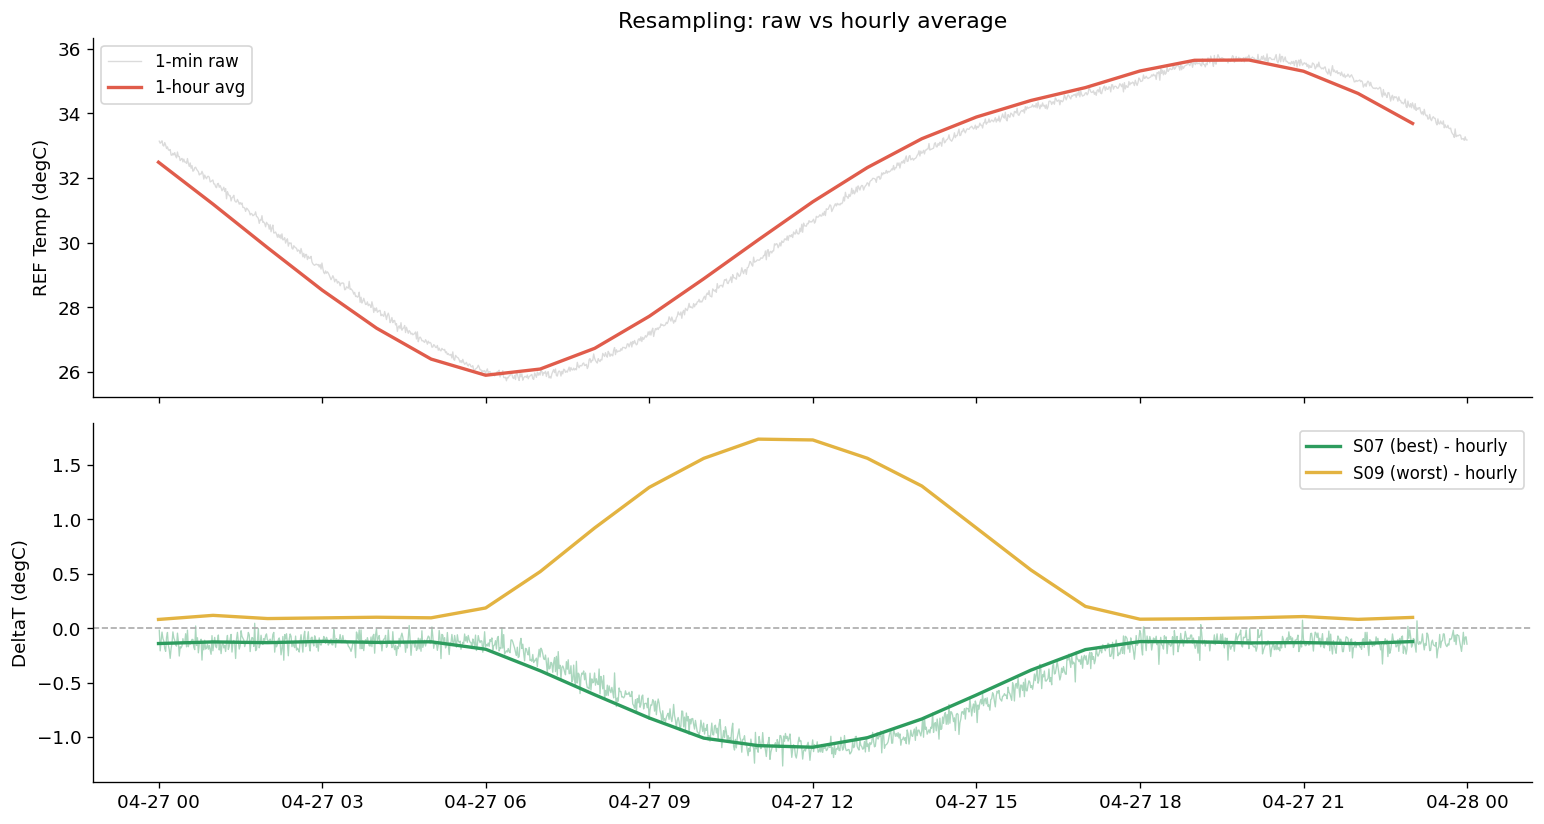

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Top: raw REF at 1-min vs 1-hour average
axes[0].plot(df.index, df['REF'], alpha=0.3, lw=0.8, color='#888', label='1-min raw')
axes[0].plot(hourly.index, hourly['REF'], lw=2, color='#e05c4b', label='1-hour avg')
axes[0].set_ylabel('REF Temp (degC)')
axes[0].legend(fontsize=10)
axes[0].set_title('Resampling: raw vs hourly average')

# Bottom: DeltaT for best vs worst
axes[1].plot(df.index, df[best], lw=0.8, alpha=0.4, color='#2d9c5e')
axes[1].plot(hourly.index, hourly[best], lw=2, color='#2d9c5e', label='S07 (best) - hourly')
axes[1].plot(hourly.index, hourly[worst], lw=2, color='#e3b341', label='S09 (worst) - hourly')
axes[1].axhline(0, color='#aaa', lw=1, ls='--')
axes[1].set_ylabel('DeltaT (degC)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/drill_02_resample.png', bbox_inches='tight')
plt.show()

**Challenge:** Resample to 6-hour blocks and find which 6-hour window has the lowest (most negative)
mean DeltaT for S07.
> Hint: `df['dT_S07'].resample('6h').mean().idxmin()`

## Drill 3 — Rolling Average
**Technique:** `df.rolling(window).mean()` — sliding window smoothing.

Different from resample: rolling keeps the original index (same number of rows).
`center=True` centers the window so the smoothed curve doesn't lag the raw signal.
Essential for noisy sensor data.

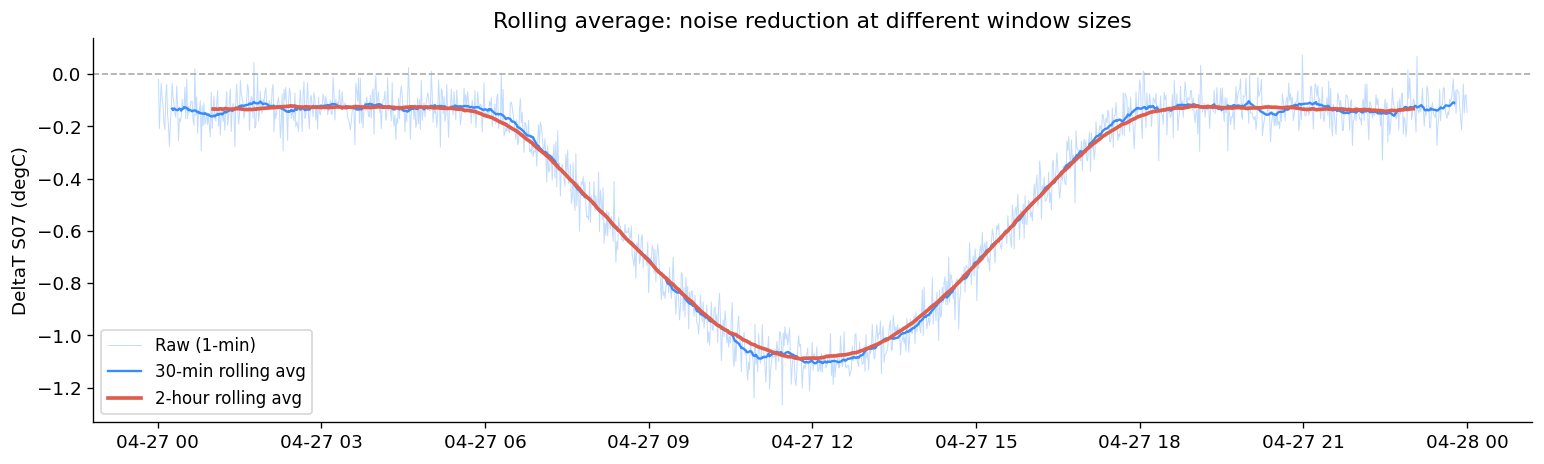

Rolling std (30-min window):
count    1411.0000
mean        0.0607
std         0.0090
min         0.0345
25%         0.0556
50%         0.0609
75%         0.0663
max         0.0863
Name: dT_S07, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(13, 4))

raw   = df['dT_S07']
r30   = df['dT_S07'].rolling(window=30,  center=True).mean()   # 30-min smooth
r120  = df['dT_S07'].rolling(window=120, center=True).mean()   # 2-hour smooth

ax.plot(raw.index,  raw,  lw=0.6, alpha=0.3, color='#388bfd', label='Raw (1-min)')
ax.plot(r30.index,  r30,  lw=1.4, color='#388bfd', label='30-min rolling avg')
ax.plot(r120.index, r120, lw=2.2, color='#e05c4b', label='2-hour rolling avg')
ax.axhline(0, color='#aaa', lw=1, ls='--')
ax.set_ylabel('DeltaT S07 (degC)')
ax.set_title('Rolling average: noise reduction at different window sizes')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/drill_03_rolling.png', bbox_inches='tight')
plt.show()

# Key stat: rolling std tells you how variable the signal is
print('Rolling std (30-min window):')
print(df['dT_S07'].rolling(30, center=True).std().describe().round(4))

**Challenge:** Compute the 60-minute rolling mean for ALL DeltaT columns at once.
> Hint: `df[sub_cols].rolling(60, center=True).mean()`

## Drill 4 — GroupBy + Agg
**Technique:** `df.groupby(by).agg({'col': ['min','mean','max']})` — split-apply-combine.

Here we create a time-of-day label (Morning / Afternoon / Night) and compute
cooling statistics per period. This pattern is identical to grouping by experiment
batch, material type, or measurement day.

In [5]:
def time_of_day(ts):
    h = ts.hour
    if 6 <= h < 12:   return 'Morning (06-12)'
    elif 12 <= h < 18: return 'Afternoon (12-18)'
    else:              return 'Night (18-06)'

df['period'] = df.index.map(time_of_day)

summary = (df.groupby('period')[sub_cols]
             .agg(['min', 'mean', 'std'])
             .round(3))

# Flatten multi-level columns for readability
summary.columns = ['_'.join(c) for c in summary.columns]

# Show just S07 for clarity
s07_cols = [c for c in summary.columns if 'S07' in c]
print(summary[s07_cols])

                   dT_S07_min  dT_S07_mean  dT_S07_std
period                                                
Afternoon (12-18)      -1.188       -0.688       0.332
Morning (06-12)        -1.266       -0.685       0.331
Night (18-06)          -0.333       -0.130       0.059


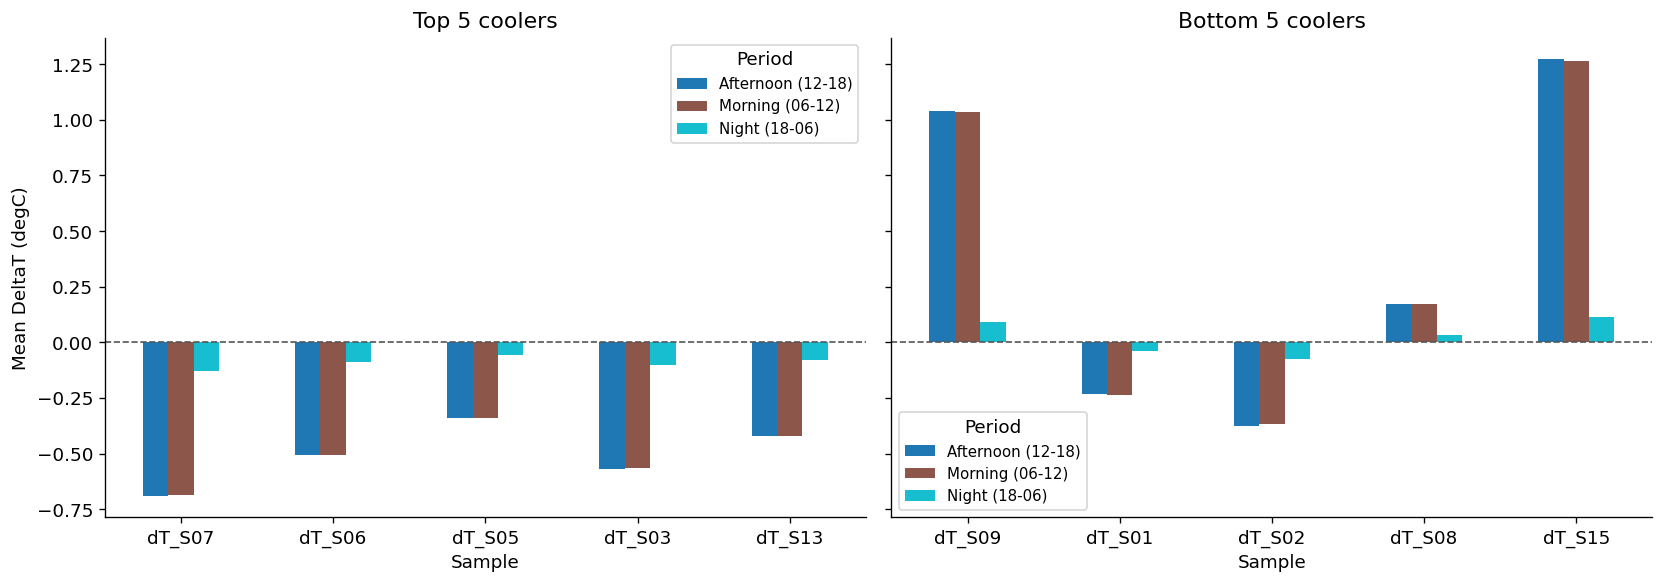

In [6]:
# Bar chart: mean DeltaT per period for top 5 and bottom 5 samples
top5    = ['dT_S07','dT_S06','dT_S05','dT_S03','dT_S13']
bottom5 = ['dT_S09','dT_S01','dT_S02','dT_S08','dT_S15']

period_mean = df.groupby('period')[sub_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, samples, title in zip(axes,
                               [top5, bottom5],
                               ['Top 5 coolers', 'Bottom 5 coolers']):
    period_mean[samples].T.plot(kind='bar', ax=ax, rot=0, colormap='tab10')
    ax.axhline(0, color='#555', lw=1, ls='--')
    ax.set_title(title)
    ax.set_ylabel('Mean DeltaT (degC)')
    ax.set_xlabel('Sample')
    ax.legend(title='Period', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/drill_04_groupby.png', bbox_inches='tight')
plt.show()

df.drop(columns='period', inplace=True)

**Challenge:** GroupBy period and compute the *percentage of minutes* where DeltaT < -0.5 degC
for S07 (i.e., how often is it cooling by more than 0.5 degC?).
> Hint: `(df['dT_S07'] < -0.5).groupby(df.index.map(time_of_day)).mean() * 100`

## Drill 5 — Melt (Wide to Long)
**Technique:** `df.melt(id_vars, value_vars, var_name, value_name)` — reshape wide to long format.

Wide format: one column per sample (current format).
Long format: one row per (timestamp, sample) observation.

Long format is required by seaborn and is cleaner for multi-sample statistical operations.

In [7]:
# Take a 15-min resampled slice to keep it manageable
df_15 = df[sub_cols].resample('15min').mean().reset_index()

# Melt: each row becomes (Time, sample_id, delta_t)
long = df_15.melt(id_vars='Time', value_vars=sub_cols,
                  var_name='sample', value_name='delta_t')
long['sample'] = long['sample'].str.replace('dT_', '')

print('Wide shape:', df_15.shape)
print('Long shape:', long.shape)
print()
print(long.head(8).round(3))

Wide shape: (96, 20)
Long shape: (1824, 3)

                 Time sample  delta_t
0 2026-04-27 00:00:00    S01   -0.011
1 2026-04-27 00:15:00    S01   -0.039
2 2026-04-27 00:30:00    S01   -0.035
3 2026-04-27 00:45:00    S01   -0.010
4 2026-04-27 01:00:00    S01   -0.048
5 2026-04-27 01:15:00    S01   -0.016
6 2026-04-27 01:30:00    S01   -0.061
7 2026-04-27 01:45:00    S01   -0.035


C:\Users\ezthu\AppData\Local\Temp\ipykernel_1808\1542834571.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(long.head(8).round(3))


C:\Users\ezthu\AppData\Local\Temp\ipykernel_1808\3266054313.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=daytime_long[daytime_long['sample'].isin(top_samples)],


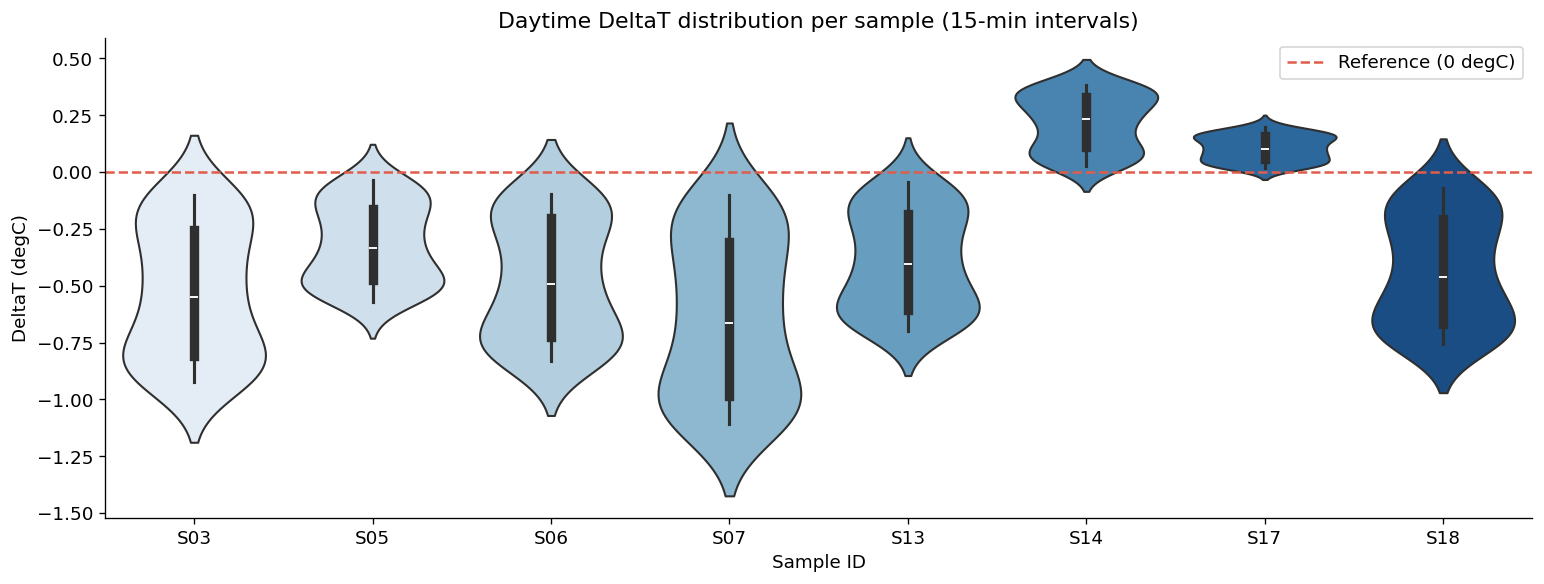

In [8]:
import seaborn as sns

# Violin plot: DeltaT distribution per sample (daytime only)
daytime_long = long[long['Time'].dt.hour.between(6, 18)]

top_samples = ['S03','S05','S06','S07','S13','S14','S17','S18']

fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=daytime_long[daytime_long['sample'].isin(top_samples)],
               x='sample', y='delta_t', palette='Blues', ax=ax,
               order=sorted(top_samples))
ax.axhline(0, color='#e05c4b', lw=1.5, ls='--', label='Reference (0 degC)')
ax.set_title('Daytime DeltaT distribution per sample (15-min intervals)')
ax.set_ylabel('DeltaT (degC)')
ax.set_xlabel('Sample ID')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/drill_05_violin.png', bbox_inches='tight')
plt.show()

**Challenge:** Using the long-format DataFrame, compute the median DeltaT per sample
across all daytime rows, then sort ascending.
> Hint: `daytime_long.groupby('sample')['delta_t'].median().sort_values()`

## Drill 6 — Annotations + Twin Axes
**Techniques:** `ax.annotate()` to label key events, `ax.twinx()` for dual Y-axis.

Use annotate when a specific data point needs a label (peak time, threshold crossing).
Use twinx when two variables have different scales but share the same time axis (e.g.
temperature + solar radiation, or DeltaT + humidity).

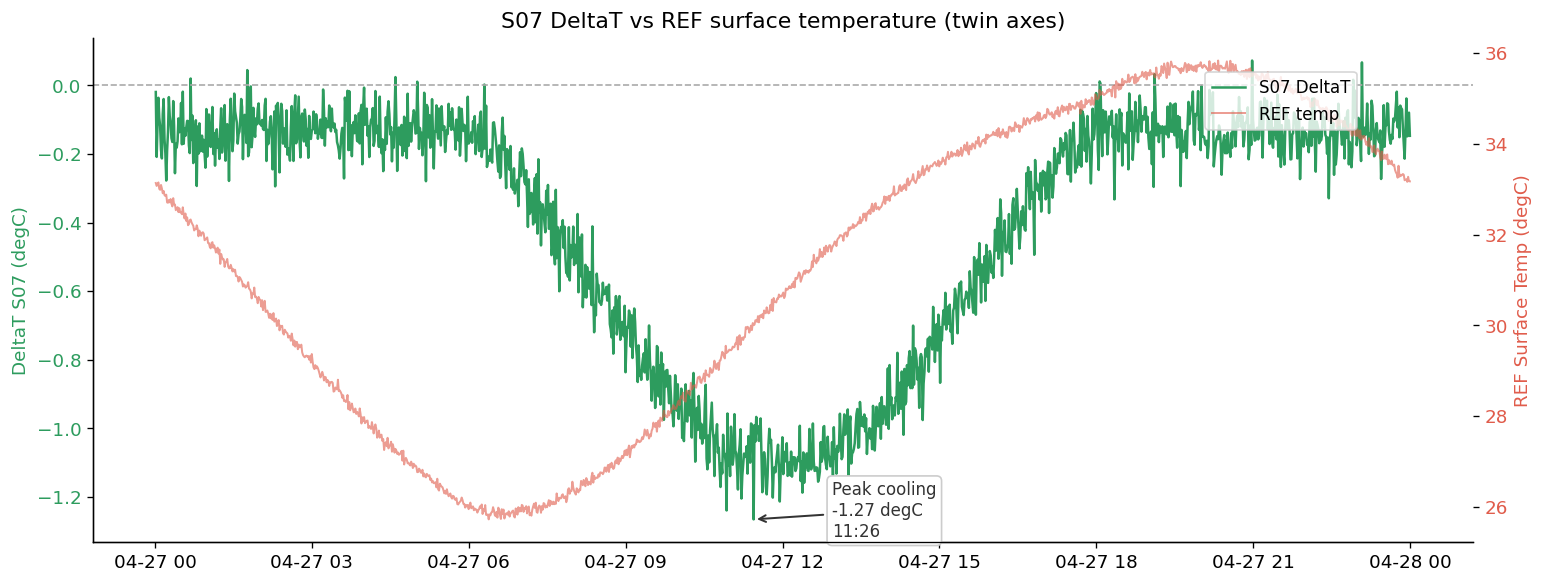

In [9]:
fig, ax1 = plt.subplots(figsize=(13, 5))

# Left axis: DeltaT for S07
ax1.plot(df.index, df['dT_S07'], lw=1.5, color='#2d9c5e', label='S07 DeltaT')
ax1.axhline(0, color='#aaa', lw=1, ls='--')
ax1.set_ylabel('DeltaT S07 (degC)', color='#2d9c5e')
ax1.tick_params(axis='y', labelcolor='#2d9c5e')

# Right axis: REF temperature
ax2 = ax1.twinx()
ax2.plot(df.index, df['REF'], lw=1.2, color='#e05c4b', alpha=0.6, label='REF temp')
ax2.set_ylabel('REF Surface Temp (degC)', color='#e05c4b')
ax2.tick_params(axis='y', labelcolor='#e05c4b')

# Annotate the peak cooling point
peak_time = df['dT_S07'].idxmin()
peak_val  = df['dT_S07'].min()
ax1.annotate(f'Peak cooling\n{peak_val:.2f} degC\n{peak_time.strftime("%H:%M")}',
             xy=(peak_time, peak_val),
             xytext=(peak_time + pd.Timedelta('90min'), peak_val - 0.05),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.2),
             fontsize=10, color='#333',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ccc'))

ax1.set_title('S07 DeltaT vs REF surface temperature (twin axes)')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88), fontsize=10)

plt.tight_layout()
plt.savefig('../figures/drill_06_twinax.png', bbox_inches='tight')
plt.show()

**Challenge:** Add a second annotation marking when REF temperature first exceeds 30 degC in the morning.
> Hint: `df[df['REF'] > 30].index[0]`

## Drill 7 — GridSpec: Custom Multi-Panel Layout
**Technique:** `matplotlib.gridspec.GridSpec` — control panel sizes precisely.

Useful for figures with a wide overview plot + narrow detail panels, or
mixing different plot types in one figure. This is standard for journal figures.

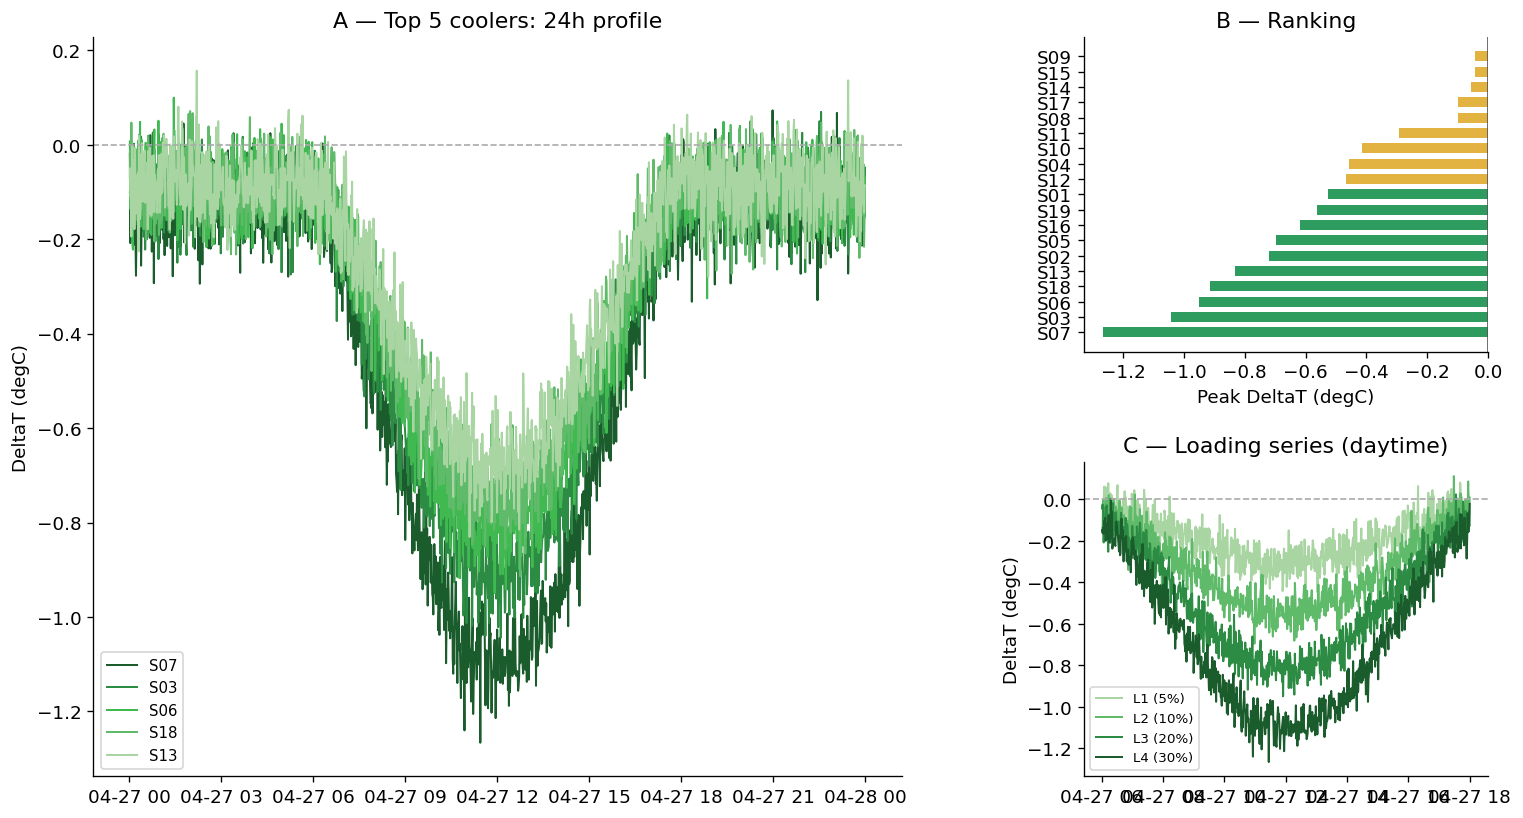

Figure saved.


In [10]:
daytime = df.between_time('06:00', '18:00')
peak_dt = daytime[sub_cols].min().sort_values()
peak_dt.index = [c.replace('dT_', '') for c in peak_dt.index]

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        width_ratios=[2, 1],
                        height_ratios=[1, 1],
                        hspace=0.35, wspace=0.3)

# Panel A (left, tall): time series for top 5 coolers
ax_a = fig.add_subplot(gs[:, 0])
top5_ids = peak_dt.index[:5]
palette  = ['#1a5c2c','#2d8c44','#3fb950','#5fba6a','#a8d5a2']
for sid, c in zip(top5_ids, palette):
    ax_a.plot(df.index, df[f'dT_{sid}'], lw=1.2, color=c, label=sid)
ax_a.axhline(0, color='#aaa', lw=1, ls='--')
ax_a.set_ylabel('DeltaT (degC)')
ax_a.set_title('A — Top 5 coolers: 24h profile')
ax_a.legend(fontsize=9)

# Panel B (top right): peak DeltaT bar chart
ax_b = fig.add_subplot(gs[0, 1])
colors_b = ['#2d9c5e' if v < -0.5 else '#e3b341' for v in peak_dt.values]
ax_b.barh(peak_dt.index, peak_dt.values, color=colors_b, height=0.65)
ax_b.axvline(0, color='#555', lw=1)
ax_b.set_xlabel('Peak DeltaT (degC)')
ax_b.set_title('B — Ranking')

# Panel C (bottom right): loading series S04-S07
ax_c = fig.add_subplot(gs[1, 1])
load_series = {'S04':'L1 (5%)','S05':'L2 (10%)','S06':'L3 (20%)','S07':'L4 (30%)'}
clrs = ['#a8d5a2','#5fba6a','#2d8c44','#1a5c2c']
for (sid, label), c in zip(load_series.items(), clrs):
    ax_c.plot(daytime.index, daytime[f'dT_{sid}'],
              lw=1.2, color=c, label=label)
ax_c.axhline(0, color='#aaa', lw=1, ls='--')
ax_c.set_ylabel('DeltaT (degC)')
ax_c.set_title('C — Loading series (daytime)')
ax_c.legend(fontsize=8)

plt.savefig('../figures/drill_07_gridspec.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

## Summary — Techniques Covered

| Drill | Technique | Key method |
|-------|-----------|-----------|
| 1 | Load + inspect | `pd.read_csv(parse_dates, index_col)`, `df.info()`, `df.describe()` |
| 2 | Resample | `df.resample('1h').mean()` |
| 3 | Rolling average | `df.rolling(window, center=True).mean()` |
| 4 | GroupBy + Agg | `df.groupby(by).agg({'col': ['min','mean']})` |
| 5 | Melt (wide to long) | `df.melt(id_vars, value_vars, var_name, value_name)` |
| 6 | Annotations + twinx | `ax.annotate()`, `ax.twinx()` |
| 7 | GridSpec layout | `gridspec.GridSpec(rows, cols, width_ratios, height_ratios)` |

**Apply to your own data:** these exact patterns work on any time-series CSV from the lab
(LFA thermal diffusivity over temperature, FTIR spectra, outdoor measurement logs).
The only change is the column names.